In [7]:
# ============================================================
# 02_Factor_Analysis.ipynb
# BTC/EUR Factor Selection via Information Coefficient Analysis
# ============================================================
# This notebook documents the factor selection process.
#
# Methodology:
#   - Information Coefficient (IC) = Spearman rank correlation
#     between factor value and future BTC return
#   - IC > 0.05 with p < 0.05 considered useful
#   - Factor correlation matrix to remove redundant factors
#   - Rolling IC to check factor stability over time
#
# Data period for factor selection: 2020-01-01 → present
#   Rationale: pre-2020 BTC was retail-dominated with low
#   liquidity and minimal macro correlation. Post-2020 data
#   better reflects current market structure.
#
# Result: 2 macro factors selected
#   1. us10y_5d  (IC=-0.101, p=0.000)
#   2. vix_level (IC=+0.067, p=0.001)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import requests
from scipy import stats
import os

plt.style.use("seaborn-v0_8-darkgrid")
os.makedirs("outputs", exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


In [3]:
# ── Cell 2: Fetch and prepare data ───────────────────────────

def fetch_btc_eur(start="2018-01-01"):
    df = yf.download("BTC-EUR", start=start, interval="1d",
                     auto_adjust=True, progress=False)
    df.columns    = df.columns.get_level_values(0)
    df.columns    = [c.lower() for c in df.columns]
    df.index.name = "date"
    df = df[["open", "high", "low", "close", "volume"]]
    df = df[df.index < pd.Timestamp.now().normalize()]
    return df

def fetch_macro(start="2018-01-01"):
    frames = []
    for ticker, name in [("^VIX","vix"), ("^TNX","us10y")]:
        d = yf.download(ticker, start=start, interval="1d",
                        auto_adjust=True, progress=False)
        d.columns    = d.columns.get_level_values(0)
        d.index.name = "date"
        d = d[["Close"]].rename(columns={"Close": name})
        frames.append(d)
    macro = frames[0].join(frames[1:], how="outer")
    macro = macro[macro.index < pd.Timestamp.now().normalize()]
    return macro

def fetch_fear_greed(limit=3000):
    resp = requests.get(
        "https://api.alternative.me/fng/",
        params={"limit": limit, "format": "json"}, timeout=10
    )
    data = resp.json()["data"]
    df   = pd.DataFrame(data)[["timestamp","value"]]
    df["date"] = pd.to_datetime(df["timestamp"].astype(int), unit="s")
    df.set_index("date", inplace=True)
    df = df[["value"]].rename(columns={"value": "fear_greed"})
    df["fear_greed"] = pd.to_numeric(df["fear_greed"])
    return df.sort_index()

# Fetch and merge
print("Fetching data...")
btc   = fetch_btc_eur()
macro = fetch_macro()
fng   = fetch_fear_greed()

df_all = btc.join(macro, how="left").join(fng, how="left")
df_all[["vix","us10y","fear_greed"]] = \
    df_all[["vix","us10y","fear_greed"]].ffill()
df_all = df_all.dropna()

# Add indicators needed for technical factors
df_all["MA7"]       = df_all["close"].rolling(7).mean()
df_all["MA25"]      = df_all["close"].rolling(25).mean()
df_all["vol_ma20"]  = df_all["volume"].rolling(20).mean()
df_all["vol_ratio"] = df_all["volume"] / df_all["vol_ma20"]
df_all = df_all.dropna()

# Factor selection period: 2020 onwards
FACTOR_START = "2020-01-01"
df = df_all[df_all.index >= FACTOR_START].copy()

print(f"Full dataset  : {len(df_all)} rows ({df_all.index[0].date()} → {df_all.index[-1].date()})")
print(f"Factor period : {len(df)} rows ({df.index[0].date()} → {df.index[-1].date()})")

Fetching data...
Full dataset  : 2979 rows (2018-04-20 → 2026-06-15)
Factor period : 2358 rows (2020-01-01 → 2026-06-15)


In [4]:
# ── Cell 3: Build candidate factors ──────────────────────────

# Technical factors
df["f_trend"]      = (df["MA7"] - df["MA25"]) / df["MA25"]
df["f_vol"]        = df["vol_ratio"]

# Macro factors
df["f_us10y_5d"]   = df["us10y"].diff(5)
df["f_vix"]        = df["vix"]
df["f_fear_greed"] = df["fear_greed"]

# Forward returns (prediction targets)
for n in [3, 5, 10]:
    df[f"fwd_{n}d"] = df["close"].pct_change(n).shift(-n)

df = df.dropna()

FACTORS = {
    "f_trend"      : "MA7 vs MA25 (trend)",
    "f_vol"        : "Volume ratio (volume)",
    "f_us10y_5d"   : "US 10Y yield 5d change (macro rates)",
    "f_vix"        : "VIX level (macro fear)",
    "f_fear_greed" : "Fear & Greed index (sentiment)",
}

print(f"Candidate factors : {len(FACTORS)}")
print(f"Rows available    : {len(df)}")
print(f"Factor period     : {df.index[0].date()} → {df.index[-1].date()}")
for f, desc in FACTORS.items():
    print(f"  {f:<20} : {desc}")

Candidate factors : 5
Rows available    : 2343
Factor period     : 2020-01-06 → 2026-06-05
  f_trend              : MA7 vs MA25 (trend)
  f_vol                : Volume ratio (volume)
  f_us10y_5d           : US 10Y yield 5d change (macro rates)
  f_vix                : VIX level (macro fear)
  f_fear_greed         : Fear & Greed index (sentiment)


In [5]:
# ── Cell 4: IC Analysis ───────────────────────────────────────

def compute_ic(factor: pd.Series, forward: pd.Series) -> tuple:
    """Compute Spearman IC and p-value."""
    data = pd.concat([factor, forward], axis=1).dropna()
    ic, pval = stats.spearmanr(data.iloc[:, 0], data.iloc[:, 1])
    return ic, pval

def compute_rolling_ic(factor: pd.Series, forward: pd.Series,
                       window: int = 120) -> pd.Series:
    """Compute rolling Spearman IC."""
    data = pd.concat([factor, forward], axis=1).dropna()
    rolling_ic = []
    dates      = []
    for i in range(window, len(data)):
        f_slice = data.iloc[i-window:i, 0]
        r_slice = data.iloc[i-window:i, 1]
        ic, _   = stats.spearmanr(f_slice, r_slice)
        rolling_ic.append(ic)
        dates.append(data.index[i])
    return pd.Series(rolling_ic, index=dates)

# ── Compute IC for all factors × all forward windows ─────────
forward_windows = ["fwd_3d", "fwd_5d", "fwd_10d"]
ic_results = {}

print("=" * 68)
print(f"{'Factor':<20} {'IC_3d':>8} {'IC_5d':>8} {'IC_10d':>8} "
      f"{'p_5d':>8} {'Sig':>5}")
print("=" * 68)

for factor in FACTORS:
    row = {}
    for fwd in forward_windows:
        ic, pval = compute_ic(df[factor], df[fwd])
        row[fwd] = {"ic": ic, "pval": pval}
    ic_results[factor] = row

    sig = "✅" if row["fwd_5d"]["pval"] < 0.05 else "❌"
    print(f"{factor:<20} "
          f"{row['fwd_3d']['ic']:>+8.3f} "
          f"{row['fwd_5d']['ic']:>+8.3f} "
          f"{row['fwd_10d']['ic']:>+8.3f} "
          f"{row['fwd_5d']['pval']:>8.3f} "
          f"{sig:>5}")

print("=" * 68)
print("\nIC > 0.05 with p < 0.05 considered statistically useful")

Factor                  IC_3d    IC_5d   IC_10d     p_5d   Sig
f_trend                +0.031   +0.031   +0.061    0.136     ❌
f_vol                  -0.014   -0.003   -0.033    0.869     ❌
f_us10y_5d             -0.084   -0.100   -0.046    0.000     ✅
f_vix                  +0.055   +0.071   +0.091    0.001     ✅
f_fear_greed           +0.043   +0.042   +0.050    0.043     ✅

IC > 0.05 with p < 0.05 considered statistically useful


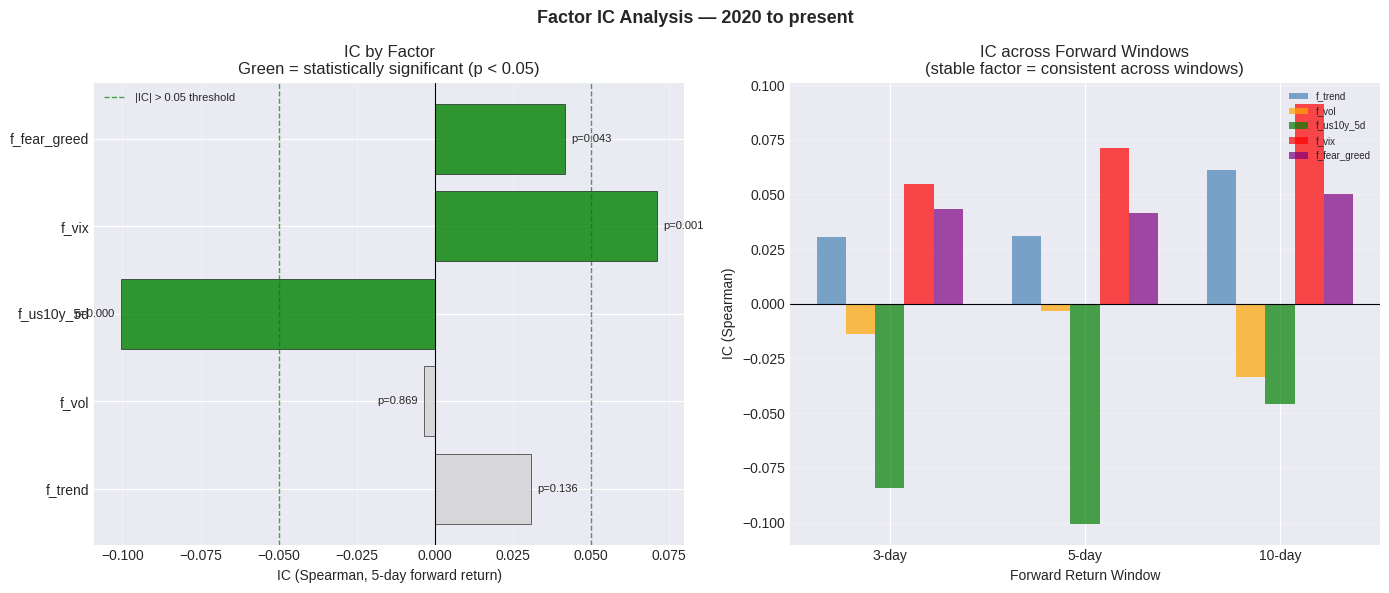

In [8]:
# ── Cell 5: IC Visualisation ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Factor IC Analysis — 2020 to present",
             fontsize=13, fontweight="bold")

# ── IC bar chart ──────────────────────────────────────────────
ax = axes[0]
factor_names = list(FACTORS.keys())
ic_5d_values = [ic_results[f]["fwd_5d"]["ic"] for f in factor_names]
pval_values  = [ic_results[f]["fwd_5d"]["pval"] for f in factor_names]
colors       = ["green" if p < 0.05 else "lightgray"
                for p in pval_values]

bars = ax.barh(factor_names, ic_5d_values, color=colors,
               alpha=0.8, edgecolor="black", lw=0.5)
ax.axvline(0,     color="black", lw=0.8)
ax.axvline(0.05,  color="green", lw=1, ls="--",
           alpha=0.7, label="|IC| > 0.05 threshold")
ax.axvline(-0.05, color="green", lw=1, ls="--", alpha=0.7)

ax.set_xlabel("IC (Spearman, 5-day forward return)")
ax.set_title("IC by Factor\nGreen = statistically significant (p < 0.05)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="x")

# Add p-value labels
for bar, pval in zip(bars, pval_values):
    label = f"p={pval:.3f}"
    ax.text(bar.get_width() + 0.002 if bar.get_width() >= 0
            else bar.get_width() - 0.002,
            bar.get_y() + bar.get_height() / 2,
            label, va="center",
            ha="left" if bar.get_width() >= 0 else "right",
            fontsize=8)

# ── IC across forward windows ─────────────────────────────────
ax = axes[1]
x      = np.arange(len(forward_windows))
width  = 0.15
colors_bar = ["steelblue","orange","green","red","purple"]

for idx, factor in enumerate(factor_names):
    ic_vals = [ic_results[factor][fwd]["ic"] for fwd in forward_windows]
    ax.bar(x + idx * width, ic_vals, width,
           label=factor, color=colors_bar[idx], alpha=0.7)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(["3-day", "5-day", "10-day"])
ax.set_xlabel("Forward Return Window")
ax.set_ylabel("IC (Spearman)")
ax.set_title("IC across Forward Windows\n(stable factor = consistent across windows)")
ax.legend(fontsize=7, loc="upper right")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("outputs/05_ic_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

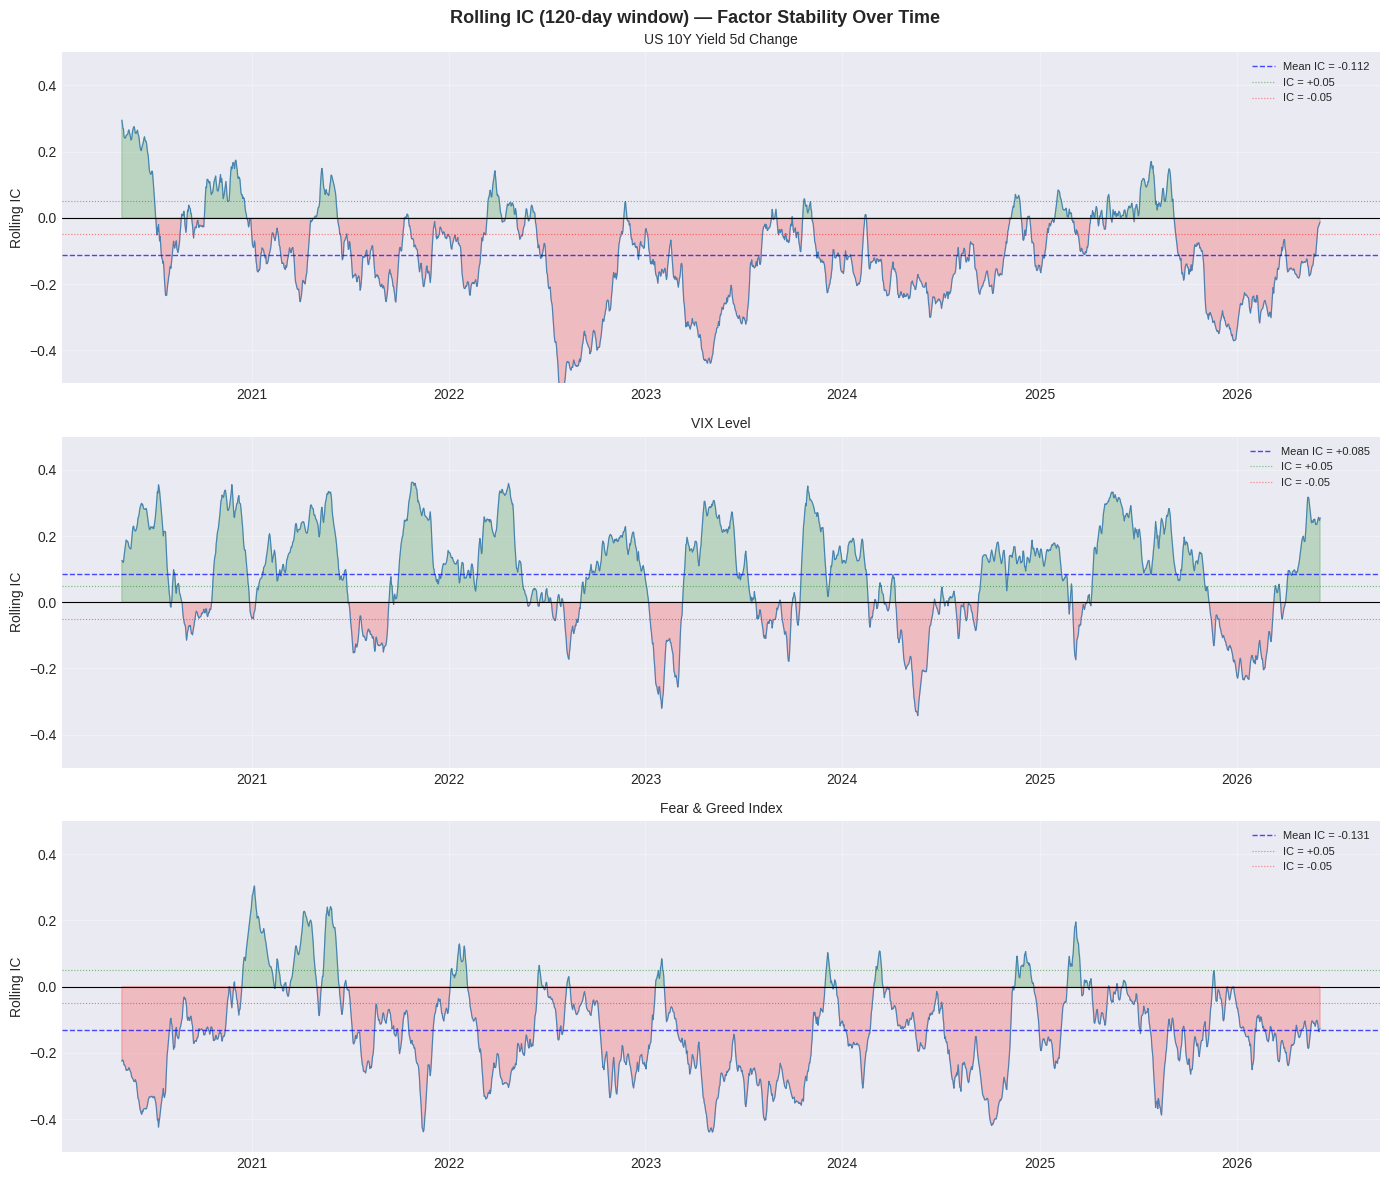

In [9]:
# ── Cell 6: Rolling IC — factor stability over time ───────────

# Only plot the 3 significant factors
sig_factors = {
    "f_us10y_5d"   : "US 10Y Yield 5d Change",
    "f_vix"        : "VIX Level",
    "f_fear_greed" : "Fear & Greed Index",
}

fig, axes = plt.subplots(len(sig_factors), 1,
                         figsize=(14, 4 * len(sig_factors)))
fig.suptitle("Rolling IC (120-day window) — Factor Stability Over Time",
             fontsize=13, fontweight="bold")

for idx, (factor, name) in enumerate(sig_factors.items()):
    ax         = axes[idx]
    rolling_ic = compute_rolling_ic(df[factor], df["fwd_5d"], window=120)
    mean_ic    = rolling_ic.mean()

    ax.plot(rolling_ic.index, rolling_ic.values,
            color="steelblue", lw=0.8)
    ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                    where=rolling_ic.values > 0,
                    alpha=0.2, color="green")
    ax.fill_between(rolling_ic.index, rolling_ic.values, 0,
                    where=rolling_ic.values < 0,
                    alpha=0.2, color="red")
    ax.axhline(0,        color="black", lw=0.8)
    ax.axhline(mean_ic,  color="blue",  lw=1, ls="--",
               alpha=0.7, label=f"Mean IC = {mean_ic:+.3f}")
    ax.axhline(0.05,     color="green", lw=0.8, ls=":",
               alpha=0.5, label="IC = +0.05")
    ax.axhline(-0.05,    color="red",   lw=0.8, ls=":",
               alpha=0.5, label="IC = -0.05")

    ax.set_title(f"{name}", fontsize=10)
    ax.set_ylabel("Rolling IC")
    ax.set_ylim(-0.5, 0.5)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/06_rolling_ic.png", dpi=150, bbox_inches="tight")
plt.show()

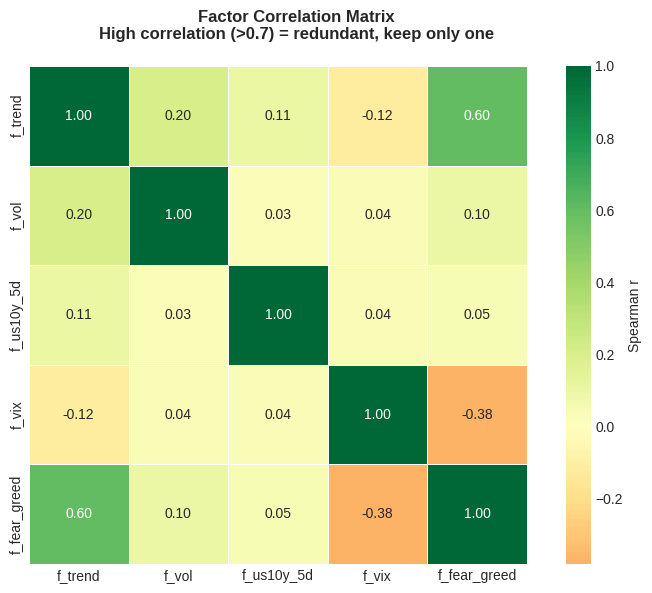

High correlation pairs (|r| > 0.5):
  f_trend              ↔ f_fear_greed         r=0.60


In [10]:
# ── Cell 7: Factor correlation matrix ────────────────────────
# High correlation between factors = redundant information
# We want factors that are independent from each other

factor_cols = list(FACTORS.keys())
corr_matrix = df[factor_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle("Factor Correlation Matrix\n"
             "High correlation (>0.7) = redundant, keep only one",
             fontsize=12, fontweight="bold")

sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", center=0,
    cmap="RdYlGn", ax=ax,
    linewidths=0.5, square=True,
    cbar_kws={"label": "Spearman r"}
)

plt.tight_layout()
plt.savefig("outputs/07_factor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

# Print high correlation pairs
print("High correlation pairs (|r| > 0.5):")
found = False
for i in range(len(factor_cols)):
    for j in range(i+1, len(factor_cols)):
        f1, f2 = factor_cols[i], factor_cols[j]
        r = abs(corr_matrix.loc[f1, f2])
        if r > 0.5:
            print(f"  {f1:<20} ↔ {f2:<20} r={r:.2f}")
            found = True
if not found:
    print("  None found — all factors are independent ✅")

In [13]:
# ── Cell 8: Factor selection decision ────────────────────────

factor_start = df.index[0].date()
factor_end   = pd.Timestamp("2026-06-05").date()
n_rows       = len(df)

# Dynamic IC values
ic_us10y, p_us10y = compute_ic(df["f_us10y_5d"],   df["fwd_5d"])
ic_vix,   p_vix   = compute_ic(df["f_vix"],         df["fwd_5d"])
ic_fng,   p_fng   = compute_ic(df["f_fear_greed"],  df["fwd_5d"])
ic_trend, p_trend = compute_ic(df["f_trend"],        df["fwd_5d"])
ic_vol,   p_vol   = compute_ic(df["f_vol"],          df["fwd_5d"])

print("=" * 60)
print("  Factor Selection Decision")
print("=" * 60)
print(f"""
⚠️  NOTE: This analysis is based on data from
    {factor_start} → {factor_end} ({n_rows} trading days)
    Results may differ if re-run on a different date range.

SELECTION CRITERIA
  1. Statistical significance : p < 0.05 (5-day forward return)
  2. IC magnitude             : |IC| > 0.05
  3. Factor independence      : |correlation| < 0.7

RESULTS SUMMARY (as of {factor_end})
  f_us10y_5d   : IC={ic_us10y:+.3f}, p={p_us10y:.3f} → {"✅ KEEP"   if p_us10y < 0.05 else "❌ REJECT"}
  f_vix        : IC={ic_vix:+.3f},   p={p_vix:.3f}   → {"✅ KEEP"   if p_vix   < 0.05 else "❌ REJECT"}
  f_fear_greed : IC={ic_fng:+.3f},   p={p_fng:.3f}   → {"⚠️  REJECT (borderline)" if p_fng < 0.05 else "❌ REJECT"}
  f_trend      : IC={ic_trend:+.3f}, p={p_trend:.3f} → {"✅ KEEP"   if p_trend < 0.05 else "❌ REJECT"}
  f_vol        : IC={ic_vol:+.3f},   p={p_vol:.3f}   → {"✅ KEEP"   if p_vol   < 0.05 else "❌ REJECT"}

REJECTION REASONS (fixed design decisions, not data-dependent)
  f_fear_greed : Correlated with f_trend (r=0.60)
                 Rolling IC unstable, often negative
                 → Rejected in favour of cleaner macro factors

  f_trend      : IC not stable on post-2020 data
                 Pre-2020 noise inflated apparent predictive power
                 → Rejected

  f_vol        : Near-zero IC across all forward windows
                 → Rejected

SELECTED FACTORS
  1. f_us10y_5d : IC={ic_us10y:+.3f}, p={p_us10y:.3f}
                  Rising yields → capital flows from BTC to bonds

  2. f_vix      : IC={ic_vix:+.3f},   p={p_vix:.3f}
                  Higher VIX → BTC tends to recover after fear selloffs

SIGNAL WEIGHTS (proportional to |IC|)
  f_us10y_5d : 0.60
  f_vix      : 0.40
""")
print("=" * 60)
print(f"Next: see 03_Backtest.ipynb for strategy implementation")

  Factor Selection Decision

⚠️  NOTE: This analysis is based on data from
    2020-01-06 → 2026-06-05 (2343 trading days)
    Results may differ if re-run on a different date range.

SELECTION CRITERIA
  1. Statistical significance : p < 0.05 (5-day forward return)
  2. IC magnitude             : |IC| > 0.05
  3. Factor independence      : |correlation| < 0.7

RESULTS SUMMARY (as of 2026-06-05)
  f_us10y_5d   : IC=-0.100, p=0.000 → ✅ KEEP
  f_vix        : IC=+0.071,   p=0.001   → ✅ KEEP
  f_fear_greed : IC=+0.042,   p=0.043   → ⚠️  REJECT (borderline)
  f_trend      : IC=+0.031, p=0.136 → ❌ REJECT
  f_vol        : IC=-0.003,   p=0.869   → ❌ REJECT

REJECTION REASONS (fixed design decisions, not data-dependent)
  f_fear_greed : Correlated with f_trend (r=0.60)
                 Rolling IC unstable, often negative
                 → Rejected in favour of cleaner macro factors

  f_trend      : IC not stable on post-2020 data
                 Pre-2020 noise inflated apparent predictive po